<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Project_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
base_data_path = dataset_path

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)

images_dir = os.path.join(dataset_path, "images", "images")

train_generator = datagen.flow_from_directory(
    images_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='input', # Changed from 'categorical' to 'input' for autoencoder training
    subset='training'
)

print(f"Total training samples: {train_generator.samples}")
print(f"Total training batches: {len(train_generator)}")

Using Colab cache for faster access to the 'best-artworks-of-all-time' dataset.
Found 7921 images belonging to 51 classes.
Total training samples: 7921
Total training batches: 248


In [19]:
def build_autoencoder(input_shape=(128, 128, 3)):
    # Encoder
    input_img = layers.Input(shape=input_shape)

    # First layer
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Second layer
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Bottleneck
    encoded = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="encoder_output")(x)

    # Decoder
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    # Output, between 0 and 1
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Conv2D)         │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,291 (79.26 KB)

 Trainable params: 20,291 (79.26 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Calculate train steps
train_steps = train_generator.samples // BATCH_SIZE

# Construct the model
autoencoder = build_autoencoder(input_shape=(128, 128, 3))

# Train the model
history = autoencoder.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=30,
    verbose=1
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 70s 263ms/step - loss: 0.0214
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 47us/step - loss: 0.0132  
Epoch 3/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


247/247 ━━━━━━━━━━━━━━━━━━━━ 60s 241ms/step - loss: 0.0111
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 64us/step - loss: 0.0091   
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 60s 244ms/step - loss: 0.0103
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 49us/step - loss: 0.0097   
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 81s 240ms/step - loss: 0.0097
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 42us/step - loss: 0.0102  
Epoch 9/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 60s 242ms/step - loss: 0.0095
Epoch 10/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 42us/step - loss: 0.0074  
Epoch 11/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 58s 236ms/step - loss: 0.0092
Epoch 12/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 46us/step - loss: 0.0086  
Epoch 13/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 59s 239ms/step - loss: 0.0091
Epoch 14/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 43us/step - loss: 0.0088  
Epoch 15/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 60s 241ms/step - loss: 0.0089
Epoch 16/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 44us/step - loss: 0.0089  
Epoch 17/30
247/247 ━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step


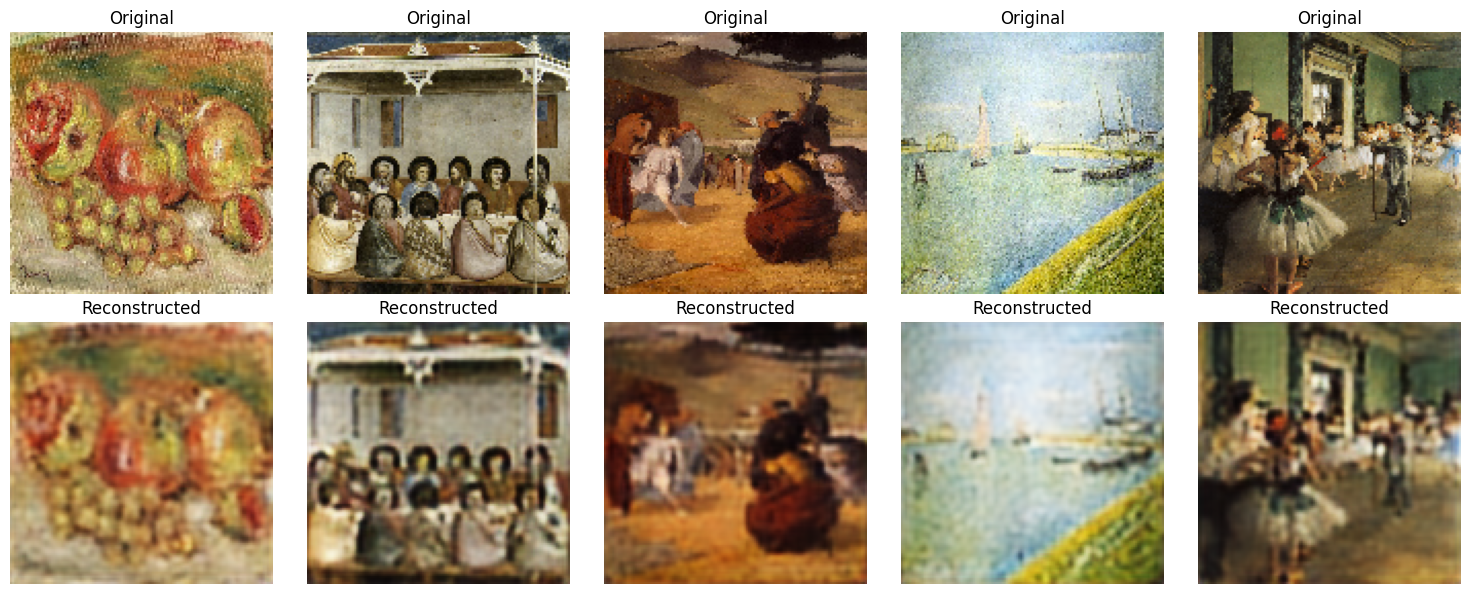

In [21]:
def visualize_reconstruction(model, generator, n_images=5):
    # Get random image
    batch_data = next(generator)
    images = batch_data[0] # Original image

    # Reconstruct prediction
    reconstructed = model.predict(images)

    plt.figure(figsize=(15, 6))
    for i in range(n_images):
        # Original
        ax = plt.subplot(2, n_images, i + 1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        ax = plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(reconstructed[i])
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Visualize
visualize_reconstruction(autoencoder, train_generator)

Found 8774 images belonging to 51 classes.


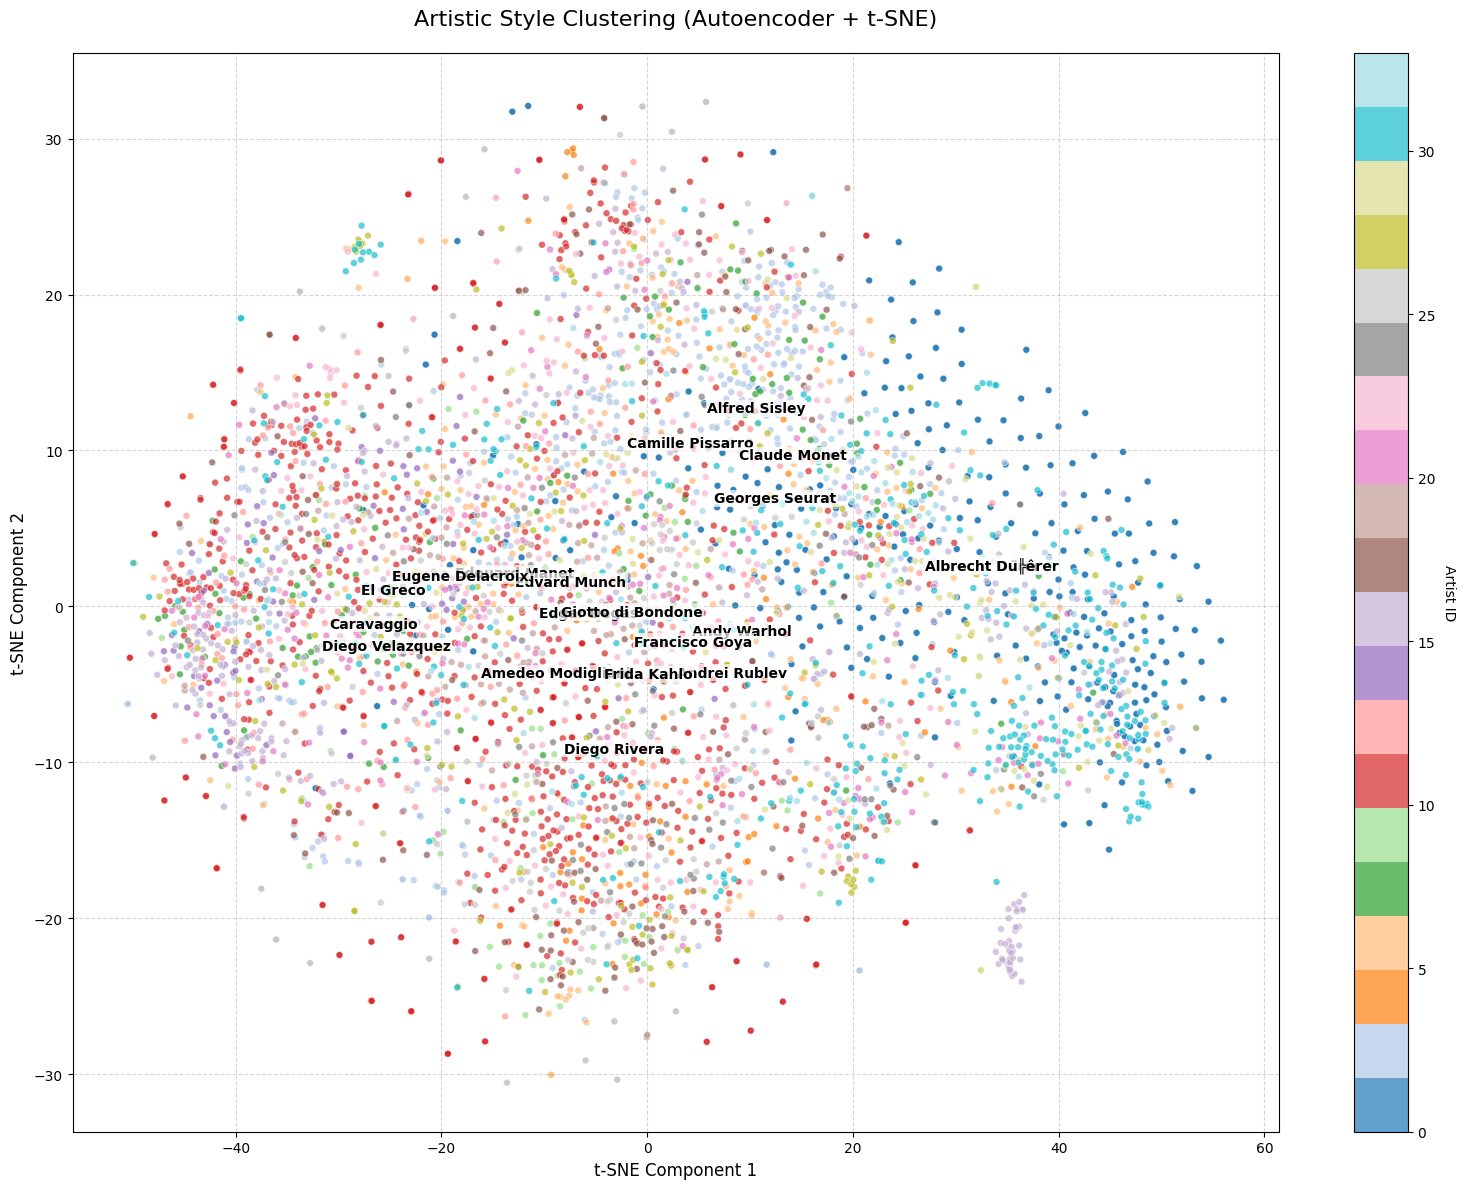

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tsne_data_path = os.path.join(dataset_path, "images", "images")
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer("encoder_output").output)

datagen_tsne = ImageDataGenerator(rescale=1./255)
tsne_generator = datagen_tsne.flow_from_directory(
    tsne_data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

all_features = []
all_labels = []
num_batches = min(len(tsne_generator), 150)

for i in range(num_batches):
    batch_x, batch_y = next(tsne_generator)
    feat = encoder.predict(batch_x, verbose=0)
    feat_flattened = feat.reshape(feat.shape[0], -1)
    all_features.append(feat_flattened)
    all_labels.append(batch_y)

X_features = np.vstack(all_features)
y_labels = np.concatenate(all_labels)

tsne = TSNE(n_components=2, perplexity=45, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_features)

label_map = {v: k for k, v in tsne_generator.class_indices.items()}
unique_labels = np.unique(y_labels)

plt.figure(figsize=(16, 12))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_labels, cmap='tab20', alpha=0.7, s=25, edgecolors='white', linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Artist ID', rotation=270, labelpad=15)

plt.title("Artistic Style Clustering (Autoencoder + t-SNE)", fontsize=16, pad=20)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)

for label in unique_labels:
    if label >= 20:
        break
    indices = np.where(y_labels == label)[0]
    if len(indices) > 0:
        centroid_x = np.mean(X_tsne[indices, 0])
        centroid_y = np.mean(X_tsne[indices, 1])
        display_name = label_map[label].replace('_', ' ')
        plt.text(centroid_x, centroid_y, display_name, fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

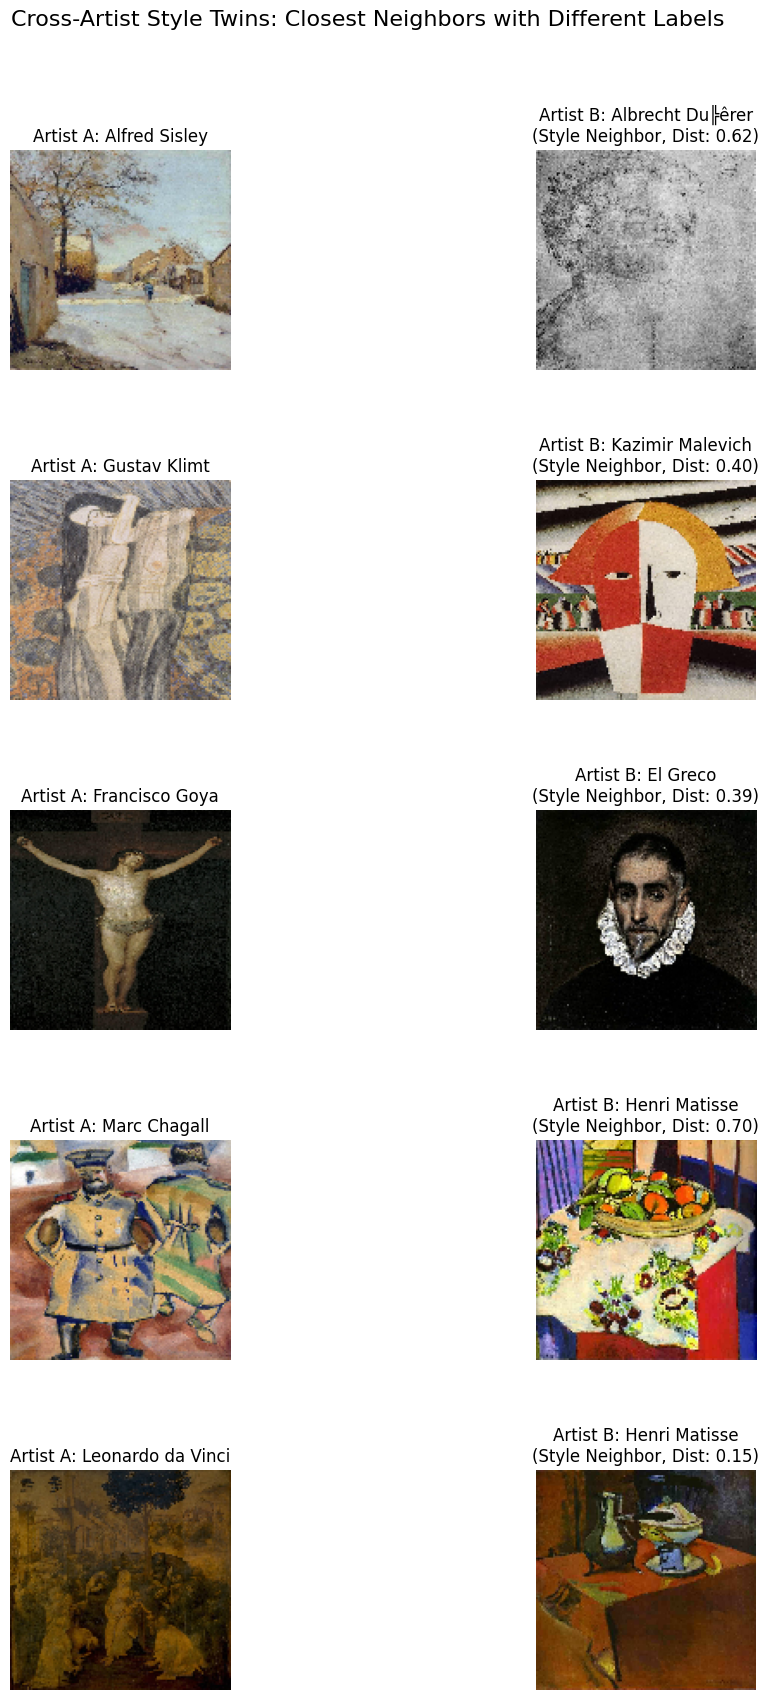

In [31]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

def verify_cross_artist_style(X_tsne, y_labels, generator, n_pairs=5):

    nn = NearestNeighbors(n_neighbors=200)
    nn.fit(X_tsne)

    pairs_found = 0
    used_indices = set()

    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4 * n_pairs))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)


    label_map = {v: k for k, v in generator.class_indices.items()}


    sample_indices = np.random.choice(len(X_tsne), len(X_tsne), replace=False)

    for i in sample_indices:
        if pairs_found >= n_pairs: break
        if i in used_indices: continue

        distances, indices = nn.kneighbors([X_tsne[i]])

        target_neighbor = None
        for neighbor_idx in indices[0][1:]:
            if y_labels[i] != y_labels[neighbor_idx]:
                target_neighbor = neighbor_idx
                break

        if target_neighbor is not None:

            img1 = generator[i // BATCH_SIZE][0][i % BATCH_SIZE]
            img2 = generator[target_neighbor // BATCH_SIZE][0][target_neighbor % BATCH_SIZE]

            name1 = label_map[y_labels[i]].replace('_', ' ')
            name2 = label_map[y_labels[target_neighbor]].replace('_', ' ')


            dist = np.linalg.norm(X_tsne[i] - X_tsne[target_neighbor])


            axes[pairs_found, 0].imshow(img1)
            axes[pairs_found, 0].set_title(f"Artist A: {name1}")
            axes[pairs_found, 0].axis('off')

            axes[pairs_found, 1].imshow(img2)
            axes[pairs_found, 1].set_title(f"Artist B: {name2}\n(Style Neighbor, Dist: {dist:.2f})")
            axes[pairs_found, 1].axis('off')

            used_indices.add(i)
            used_indices.add(target_neighbor)
            pairs_found += 1

    plt.suptitle("Cross-Artist Style Twins: Closest Neighbors with Different Labels", fontsize=16, y=0.95)
    plt.show()


verify_cross_artist_style(X_tsne, y_labels, tsne_generator)

Projecting forgery into style space...


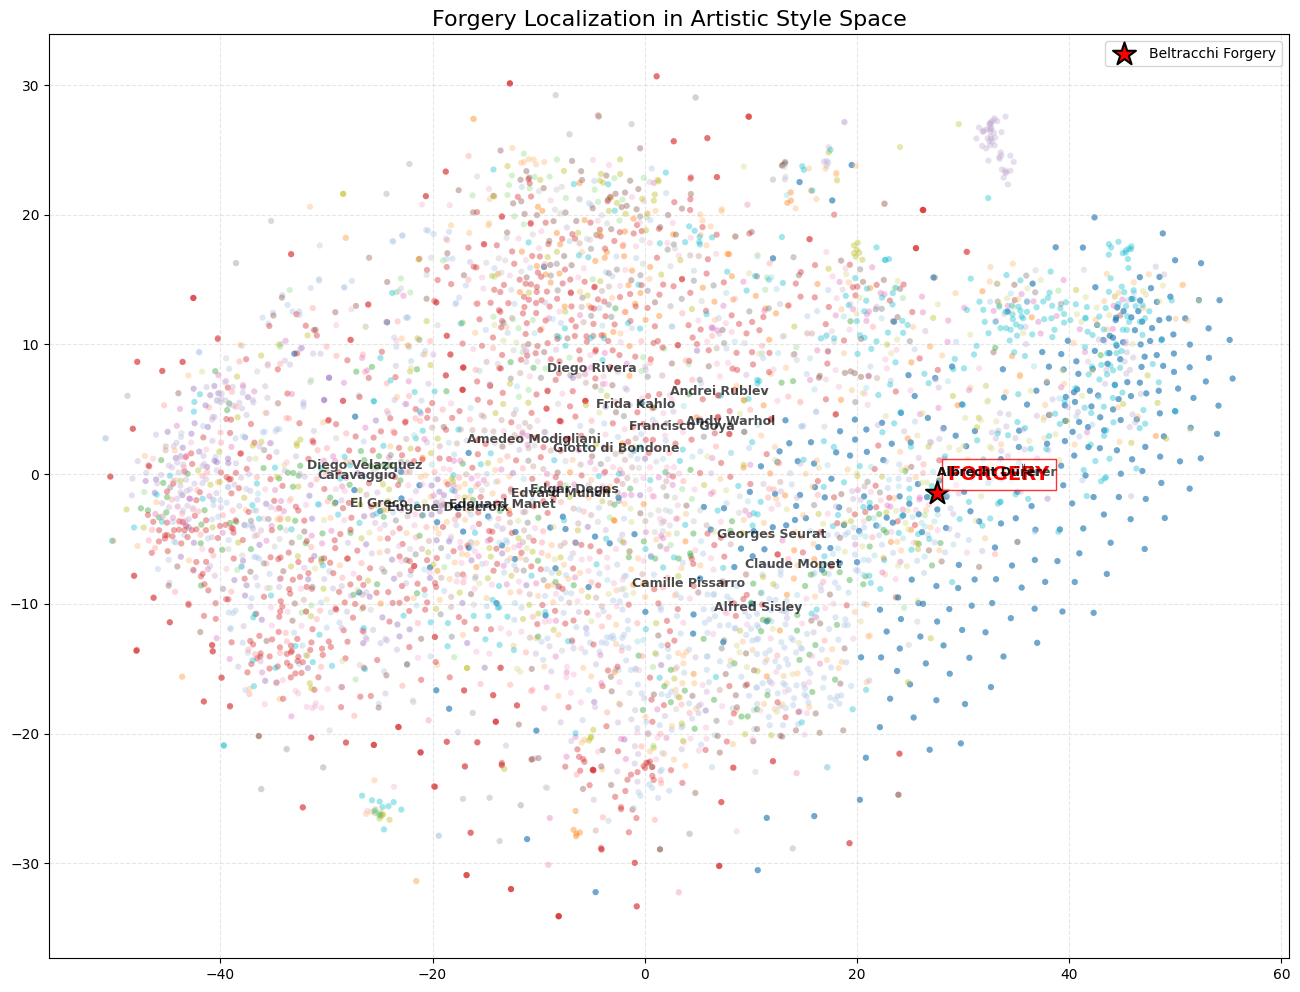

In [27]:
from tensorflow.keras.preprocessing import image

forgery_path = 'test.png'
img = image.load_img(forgery_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

forgery_feat = encoder.predict(img_array, verbose=0)
forgery_feat_flattened = forgery_feat.reshape(1, -1)


X_combined = np.vstack([X_features, forgery_feat_flattened])
y_combined = np.append(y_labels, 99)


print("Projecting forgery into style space...")
tsne_final = TSNE(n_components=2, perplexity=45, random_state=42, init='pca', learning_rate='auto')
X_tsne_combined = tsne_final.fit_transform(X_combined)

plt.figure(figsize=(16, 12))

plt.scatter(X_tsne_combined[:-1, 0], X_tsne_combined[:-1, 1],
            c=y_combined[:-1], cmap='tab20', alpha=0.4, s=20, edgecolors='none')


forgery_point = X_tsne_combined[-1]
plt.scatter(forgery_point[0], forgery_point[1],
            c='red', marker='*', s=300, label='Beltracchi Forgery', edgecolors='black', linewidth=1.5)


plt.text(forgery_point[0] + 1, forgery_point[1] + 1, "FORGERY",
         color='red', fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

for label in unique_labels[:20]:
    indices = np.where(y_combined[:-1] == label)[0]
    if len(indices) > 0:
        cx, cy = np.mean(X_tsne_combined[indices, 0]), np.mean(X_tsne_combined[indices, 1])
        plt.text(cx, cy, label_map[label].replace('_', ' '), fontsize=9, alpha=0.7, fontweight='bold')

plt.title("Forgery Localization in Artistic Style Space", fontsize=16)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()